<a href="https://colab.research.google.com/github/goonygoon84/QuasarCluster/blob/main/Quasar_Classification_Google_Analytics_Certification_Capston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quasar Classification

Google Analytics Certification Capstone Case Study

Paul Van Hecke

May 10, 2026

## Ask
The goal of this study is to determine whether quasars can be grouped into meaningful categories based on observable properties collected through astronomical surveys. I am no astrophysicist, so this is a case study to pose the questions, as an outsider, using only the data I have available to me, and without formal training and biases on the subject, whether unsupervised clustering techniques can identify meaningful groupings within quasar survey data based on observable properties. Where are the overlaps of current classification techniques?

Key metrics that will be used in this study:
* Redshift (z)	- Distance / age indicator
* Magnitude	- Brightness
* RA	- Sky longitude
* DEC	- Sky latitude
* Color bands	- Light measurements in filters
* Spectral confidence	- Observation quality
* Emission strengths	- Spectral characteristics


## Prepare
Data will be pulled from cosmology surveys.
The first of which will be the SDSS DR16Q Quasar Catalog
This is a catalog of 750,000+ quasars

# Data Collection

Sloan Digital Sky Survey - DR16Q_v4

The catalog contains spectroscopic and photometric data for over 750,000 quasars.

[Data Model](https://data.sdss.org/datamodel/files/BOSS_QSO/DR16Q/DR16Q_v4.html)

[Data download link](https://data.sdss.org/sas/dr16/eboss/qso/DR16Q/DR16Q_v4.fits)

In [4]:
# install libraries we will use
!pip install astropy pandas numpy matplotlib scikit-learn

In [6]:
# Opening FITS file

from astropy.io import fits

fits_file = "DR16Q_v4.fits"

hdul = fits.open(fits_file)

hdul.info()

Filename: DR16Q_v4.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  CATALOG       1 BinTableHDU    375   750414R x 183C   [18A, D, D, J, J, I, 6A, 6A, I, D, I, D, I, I, I, K, D, I, I, D, I, D, I, D, D, I, D, 12A, D, J, 19A, D, K, D, D, K, D, D, K, D, D, K, D, D, K, D, D, K, D, D, K, D, E, 5D, 5D, 5D, E, D, D, D, D, D, D, D, D, K, K, K, K, K, K, J, J, J, 74J, 74J, 74I, 74I, B, J, 3A, J, J, J, D, D, D, D, 14A, J, D, 5E, 5D, 5E, 5D, 5E, D, D, I, D, D, D, D, I, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, I, E, E, E, E, E, E, E, E, E, I, I, D, D, D, D, D, D, J, D, D, D, J, D, D, D, J, D, 21A, D, D, E, E, D, K, D, D, E, E, E, E, E, E, E, D, I, 28A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   


In [7]:
# Load the table
data = hdul[1].data

In [8]:
# View abridged columns
cols = data.columns.names

for c in cols[:50]:
  print(c)


SDSS_NAME
RA
DEC
PLATE
MJD
FIBERID
AUTOCLASS_PQN
AUTOCLASS_DR14Q
IS_QSO_QN
Z_QN
RANDOM_SELECT
Z_10K
Z_CONF_10K
PIPE_CORR_10K
IS_QSO_10K
THING_ID
Z_VI
Z_CONF
CLASS_PERSON
Z_DR12Q
IS_QSO_DR12Q
Z_DR7Q_SCH
IS_QSO_DR7Q
Z_DR6Q_HW
Z_DR7Q_HW
IS_QSO_FINAL
Z
SOURCE_Z
Z_PIPE
ZWARNING
OBJID
Z_PCA
ZWARN_PCA
DELTACHI2_PCA
Z_HALPHA
ZWARN_HALPHA
DELTACHI2_HALPHA
Z_HBETA
ZWARN_HBETA
DELTACHI2_HBETA
Z_MGII
ZWARN_MGII
DELTACHI2_MGII
Z_CIII
ZWARN_CIII
DELTACHI2_CIII
Z_CIV
ZWARN_CIV
DELTACHI2_CIV
Z_LYA


In [10]:
# Import numpy and pandas
import numpy as np
import pandas as pd

# Define the path to the FITS file stored in mounted Google Drive.
fits_file = "/drive/MyDrive/DR16Q_v4_data/DR16Q_v4.fits"

# confirm shape of PSFMAG
print(data["PSFMAG"].shape)

(750414, 5)


In [14]:
# Since PSFMAG has 5 values, split the values into it's individual bands u, g, r, i, z
# extract array
psfmag = data["PSFMAG"]

# Create dataframe for the metrics:
# RA Right ascension in decimal degrees (Sky coords)
# DEC Declination in decimal degrees (Sky coords)
# Z Best available redshift taken from Z_VI, Z_PIPE, Z_DR12Q, Z_DR7Q_SCH, Z_DR6Q_HW, and Z_10K
# PSFMAG_u Point spread Function (PSF) magnitudes in u band
# PSFMAG_g Point spread Function (PSF) magnitudes in g band
# PSFMAG_r Point spread Function (PSF) magnitudes in r band
# PSFMAG_i Point spread Function (PSF) magnitudes in i band
# PSFMAG_z Point spread Function (PSF) magnitudes in z band
df = pd.DataFrame({
    "ra": data["RA"],
    "dec": data["DEC"],
    "redshift": data["Z"],
    "psfmag_u": psfmag[:, 0],
    "psfmag_g": psfmag[:, 1],
    "psfmag_r": psfmag[:, 2],
    "psfmag_i": psfmag[:, 3],
    "psfmag_z": psfmag[:, 4]
})

# Display a few rows to verify
df.head()

,ra,dec,redshift,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z
0,0.000629,35.517841,0.845435,18.964045,18.630692,18.429541,18.411808,18.255451
1,0.001415,31.057048,2.035491,22.082529,21.787088,21.562086,21.359495,20.934025
2,0.001535,7.064129,1.574227,22.517344,22.102839,21.854153,21.637999,21.888760
3,0.001526,27.732283,1.770552,22.347525,21.903051,21.752844,21.663532,21.994589
4,0.001914,9.385637,2.024146,18.766439,18.662741,18.499794,18.336531,18.158636


# Now we have a dataset, lets get to cleaning

In [15]:
# Check shape
print(df.shape)

(750414, 8)


In [17]:
# Drop rows with NaN values
df_clean = df.dropna()

# Check shape
print(df_clean.shape)

(750414, 8)


No rows containing NaN, how wonderfully scientific. You love to see it.

In [26]:
# Finding data types
df.dtypes


,0
ra,>f8
dec,>f8
redshift,>f8
psfmag_u,>f4
psfmag_g,>f4
psfmag_r,>f4
psfmag_i,>f4
psfmag_z,>f4


In [28]:
# Converting data to Little-Endian, to better work with pandas/numpy

# Creating a copy of the dataframe and converting to float64
df_float = df.copy()

for col in df_float.columns:
  df_float[col] = df_float[col].astype("float64")

# Confirm new data types
df_float.dtypes

,0
ra,float64
dec,float64
redshift,float64
psfmag_u,float64
psfmag_g,float64
psfmag_r,float64
psfmag_i,float64
psfmag_z,float64


In [34]:
# Describe dataframe
df_float.describe()

,ra,dec,redshift,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z
count,750414.000000,750414.000000,750414.000000,750414.000000,750414.000000,750414.000000,750414.000000,750414.000000
mean,172.896929,27.723363,1.735272,7.764474,7.244481,7.084609,6.935857,6.782024
std,97.132120,18.722450,2.428823,368.093980,368.255731,367.522499,367.517017,367.511353
min,0.000629,-17.520442,-999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,126.859314,11.128034,1.177826,20.528543,20.166273,19.955476,19.810452,19.671975
50%,175.218036,29.456572,1.692095,21.351956,20.949136,20.719317,20.561090,20.372000
75%,228.304192,42.541897,2.260000,22.013355,21.563338,21.344405,21.183059,20.973871
max,359.999954,84.431413,7.023917,30.888962,26.311369,26.588125,29.951653,24.465014


Looks like we have some nasty placeholder values. There are several minimum values that appear as -999.0 and -9999.0. This will need to be removed so that we can get a better look at the actual data.

In [30]:
# Creating a copy of the float data frame to continue with the cleaning
df_clean = df_float.copy()

In [31]:
# Removing placeholder values of -999/-9999
df_clean = df_clean[
    (df_clean["redshift"] != -999) &
    (df_clean["psfmag_u"] != -9999) &
    (df_clean["psfmag_g"] != -9999) &
    (df_clean["psfmag_r"] != -9999) &
    (df_clean["psfmag_i"] != -9999) &
    (df_clean["psfmag_z"] != -9999)
]

# Display new shape
print(df_clean.shape)

(749395, 8)


Looks like we removed about 750,414 - 749,395 = 1,019 rows with placeholder information. This should give us new values for our statistical outlook of the dataset.

In [33]:
# Describe the dataset
df_clean.describe()

,ra,dec,redshift,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z
count,749395.000000,749395.000000,749395.000000,749395.000000,749395.000000,749395.000000,749395.000000,749395.000000
mean,172.894314,27.742574,1.740589,21.304462,20.797134,20.583568,20.434615,20.280575
std,97.108458,18.715305,0.748836,1.277973,1.015257,1.000230,0.993714,0.988441
min,0.000629,-17.520442,-0.002643,14.247252,14.388747,14.459476,14.084700,14.375872
25%,126.878193,11.179676,1.177853,20.532919,20.170279,19.959495,19.814259,19.675711
50%,175.213326,29.475945,1.692104,21.353756,20.951025,20.721058,20.562897,20.373692
75%,228.276329,42.552994,2.260000,22.014369,21.564079,21.345245,21.183985,20.974701
max,359.999954,84.431413,7.023917,30.888962,26.311369,26.588125,29.951653,24.465014


Those means and standard deviations seem much more realistic.

In [35]:
# Astronomers use color indices to measure the difference in brightness between wavelengths
# This next step will set up and populate those indices
df_clean["u_g"] = df_clean["psfmag_u"] - df_clean["psfmag_g"]
df_clean["g_r"] = df_clean["psfmag_g"] - df_clean["psfmag_r"]
df_clean["r_i"] = df_clean["psfmag_r"] - df_clean["psfmag_i"]
df_clean["i_z"] = df_clean["psfmag_i"] - df_clean["psfmag_z"]

# Display to confirm new columns
df_clean.head()

/tmp/ipykernel_5049/267293897.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["u_g"] = df_clean["psfmag_u"] - df_clean["psfmag_g"]
/tmp/ipykernel_5049/267293897.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["g_r"] = df_clean["psfmag_g"] - df_clean["psfmag_r"]
/tmp/ipykernel_5049/267293897.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

,ra,dec,redshift,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z,u_g,g_r,r_i,i_z
0,0.000629,35.517841,0.845435,18.964045,18.630692,18.429541,18.411808,18.255451,0.333353,0.201151,0.017733,0.156357
1,0.001415,31.057048,2.035491,22.082529,21.787088,21.562086,21.359495,20.934025,0.295441,0.225002,0.202591,0.425470
2,0.001535,7.064129,1.574227,22.517344,22.102839,21.854153,21.637999,21.888760,0.414505,0.248686,0.216154,-0.250761
3,0.001526,27.732283,1.770552,22.347525,21.903051,21.752844,21.663532,21.994589,0.444473,0.150208,0.089312,-0.331057
4,0.001914,9.385637,2.024146,18.766439,18.662741,18.499794,18.336531,18.158636,0.103699,0.162947,0.163263,0.177895


In [36]:
# Describing the redshift and color indices
df_clean[
    [
        "redshift",
        "u_g",
        "g_r",
        "r_i",
        "i_z"
    ]
].describe()

,redshift,u_g,g_r,r_i,i_z
count,749395.000000,749395.000000,749395.000000,749395.000000,749395.000000
mean,1.740589,0.507328,0.213565,0.148953,0.154041
std,0.748836,0.686752,0.270661,0.204338,0.297473
min,-0.002643,-6.921572,-6.209869,-9.759331,-5.162354
25%,1.177853,0.123954,0.059591,0.019796,-0.002039
50%,1.692104,0.332758,0.178093,0.131653,0.152090
75%,2.260000,0.645602,0.320490,0.263234,0.316103
max,7.023917,8.954210,6.920073,6.388269,9.745182


Time for some histogram magic

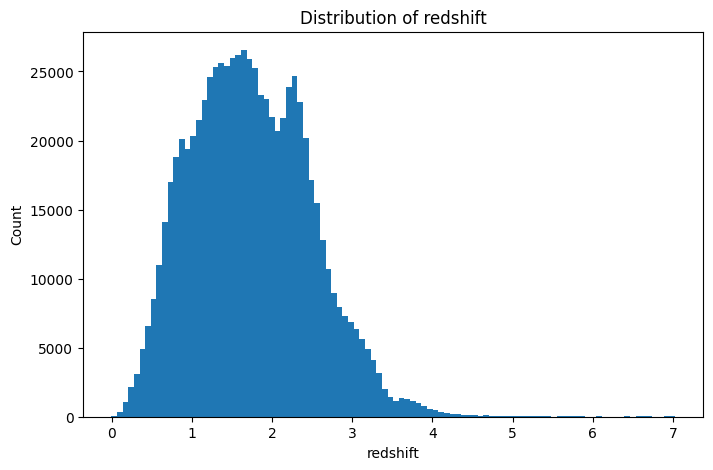

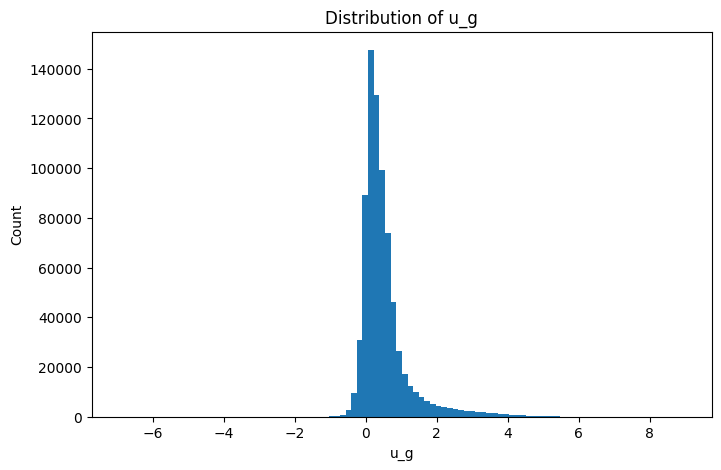

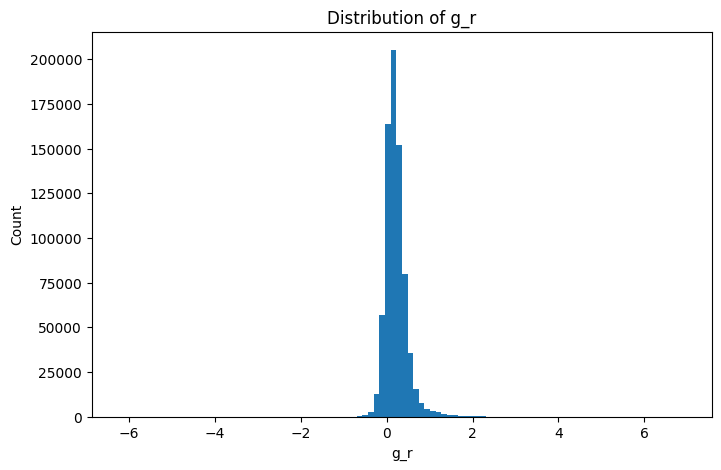

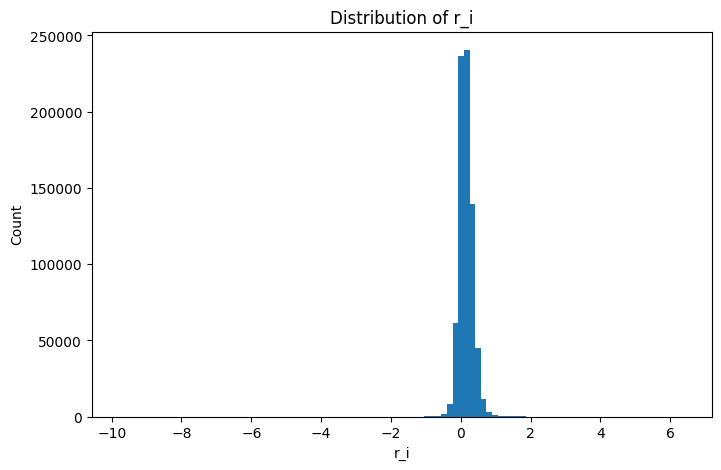

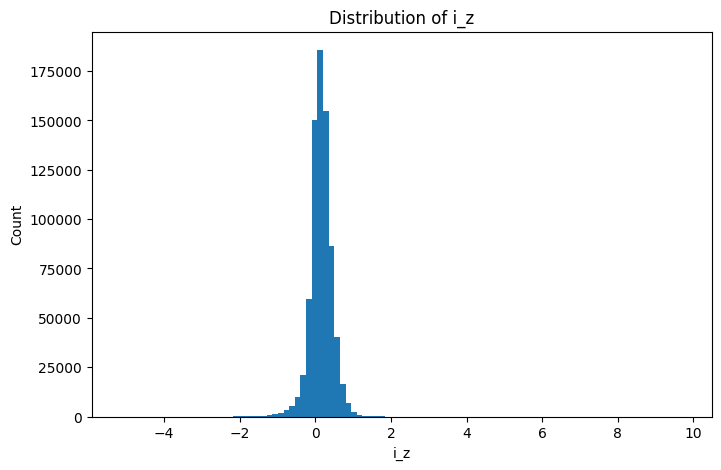

In [37]:
# import library
import matplotlib.pyplot as plt

# Grab clustering features
features = [
    "redshift",
    "u_g",
    "g_r",
    "r_i",
    "i_z"
]

# Create histograms for each
for feature in features:
  plt.figure(figsize=(8,5))

  plt.hist(df_clean[feature], bins=100)

  plt.xlabel(feature)
  plt.ylabel("Count")

  plt.title(f"Distribution of {feature}")

  plt.show()

Alrighty, we got some visuals.

Right off the bat, we have a strong right skew on the redshift with a very long tail. Some peaks and valleys around 1.5 and 2.25-ish. We will have to delve into the actual numbers to extract the exact.

On the Color indices we have some long tails, be generally pretty compact and centered.

We'll need to perform a little more shaping, but the data looks like a good starting point!

I think these will be out cluster points. The other data we have, specifically the spacial locations (RA/DEC) are not needed, and we can also drop the raw magnitudes for the clustering.





In [38]:
# Creating out Cluster data frame
cluster_features = df_clean[
    [
        "redshift",
        "u_g",
        "g_r",
        "r_i",
        "i_z"
    ]
].copy()

# Preview new dataframe
cluster_features.head()

,redshift,u_g,g_r,r_i,i_z
0,0.845435,0.333353,0.201151,0.017733,0.156357
1,2.035491,0.295441,0.225002,0.202591,0.425470
2,1.574227,0.414505,0.248686,0.216154,-0.250761
3,1.770552,0.444473,0.150208,0.089312,-0.331057
4,2.024146,0.103699,0.162947,0.163263,0.177895


Ok, we are now going to start preparing the data for the K-Means clustering.

Firstly we will use the StandardScaler tool from scikit-learn. We are doing this so out major outliers don't too heavily influence the Euclidean distance calculations.

In [39]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Creating scaler object
scaler = StandardScaler()

# Slam a new dataset and transform values
scaled_features = scaler.fit_transform(cluster_features)

# Display shape
print(scaled_features.shape)

(749395, 5)


The dataset here is pretty large, and we would do well to use a random sample to perform the calculations.

We are also going to use a few methods to justify our K score.
* Elbow
* Silhouette
* Visual

Just to make sure we get a good justification.


In [42]:
# Set up a random seed
np.random.seed(42) #obviously 42

# Setting up the sample
sample_size = 50000

sample_indices = np.random.choice(
    scaled_features.shape[0],
    sample_size,
    replace=False
)

scaled_sample = scaled_features[sample_indices]

# Confirm shape
print(scaled_sample.shape)

(50000, 5)


Perfect, we now have a random sample set, and we can begine or elbowing

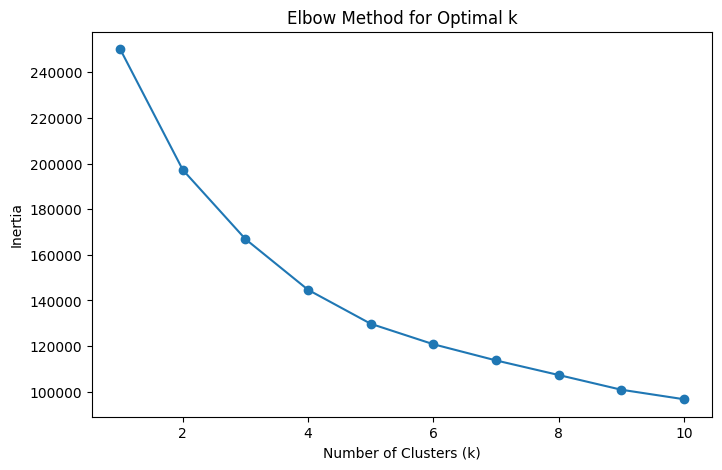

In [43]:
# Import KMeans
from sklearn.cluster import KMeans

# Create list for inertia storage
inertias = []

# Create range
cluster_range = range(1,11)

# Create model
for k in cluster_range:
  kmeans = KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )

  #Fit model to sample
  kmeans.fit(scaled_sample)

  # Store inertia values
  inertias.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8,5))

plt.plot(cluster_range, inertias, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal k")

plt.show()

Looks like we have a pretty gradual curve. breaking around 4 or 5. The gradual nature of the graph means we are likely to have overlap in categories.

Lets look at a second metric for this, silhouette scores. This should give us an indication of how well separated the cluster would be.

In [44]:
# Import silhouette_score
from sklearn.metrics import silhouette_score

# Create dict to store scores
silhouette_scores = {}

# Testing silhouette scores for 2-10
for k in range(2, 11):
  # Crete Model
  kmeans = KMeans(
      n_clusters=k,
      random_state=42,
      n_init=10
  )

  cluster_labels = kmeans.fit_predict(scaled_sample)

  # Calc silhouette
  score = silhouette_score(
      scaled_sample,
      cluster_labels
  )

  silhouette_scores[k] = score

  print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.2822
k=3, silhouette score=0.2359
k=4, silhouette score=0.2416
k=5, silhouette score=0.2514
k=6, silhouette score=0.2316
k=7, silhouette score=0.2329
k=8, silhouette score=0.2285
k=9, silhouette score=0.2312
k=10, silhouette score=0.2260


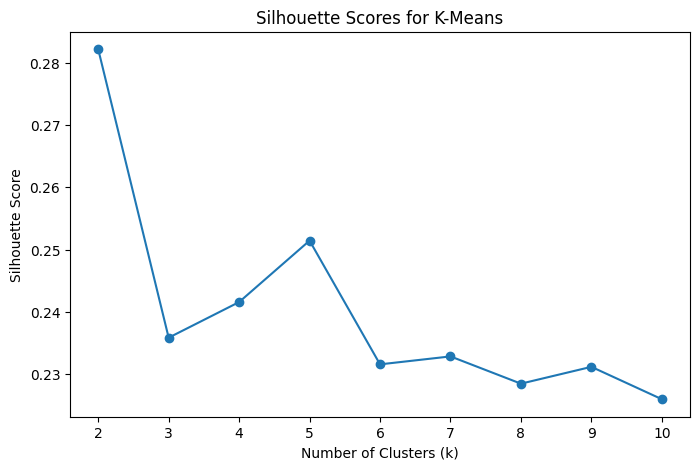

In [45]:
# Plot
plt.figure(figsize=(8,5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o'
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.title("Silhouette Scores for K-Means")

plt.show()

SO, some interesting results here. We have an overall peak at 2, which could just be Red vs Blue or some big spectral division. The additional peak at 5 is a little more exciting for me. It means there is some alignment there with the elbow method, and might meean there is a more analytically interesting division at k=5 for a more nuanced subgrouping for the quasar population.

Let's run with k=5

In [47]:
# Creating clustering model with 5 clusters
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit model and assign labels
cluster_labels = final_kmeans.fit_predict(scaled_features)

# Add clusters into dataframe
df_clean["cluster"] = cluster_labels

# Preview
df_clean.head()

,ra,dec,redshift,psfmag_u,psfmag_g,psfmag_r,psfmag_i,psfmag_z,u_g,g_r,r_i,i_z,cluster
0,0.000629,35.517841,0.845435,18.964045,18.630692,18.429541,18.411808,18.255451,0.333353,0.201151,0.017733,0.156357,3
1,0.001415,31.057048,2.035491,22.082529,21.787088,21.562086,21.359495,20.934025,0.295441,0.225002,0.202591,0.425470,0
2,0.001535,7.064129,1.574227,22.517344,22.102839,21.854153,21.637999,21.888760,0.414505,0.248686,0.216154,-0.250761,2
3,0.001526,27.732283,1.770552,22.347525,21.903051,21.752844,21.663532,21.994589,0.444473,0.150208,0.089312,-0.331057,2
4,0.001914,9.385637,2.024146,18.766439,18.662741,18.499794,18.336531,18.158636,0.103699,0.162947,0.163263,0.177895,2


We now have clusters assigned to our data from 0 to 4. Now we have to figure out what those numbers actually mean. First lets figure out the rarity of the clusters by looking at how many quasars are in each bucket.

In [48]:
# Count quasars in buckets
cluster_counts = df_clean["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    204654
1     42691
2    202048
3    232982
4     67020
Name: count, dtype: int64


cluster

0    204654

1     42691

2    202048

3    232982

4     67020

Name: count, dtype: int64

Ok, we like that. Good news is we don't have an issue with 1 or 2 clusters containing the moajority. Lets do a relative distribution for fun.

| Cluster ID | Raw Count | Relative Share (%) |
| :---: | ---: | ---: |
| 0 | 204,654 | 27.3% |
| 1 | 42,691 | 5.7% |
| 2 | 202,048 | 27.0% |
| 3 | 232,982 | 31.1% |
| 4 | 67,020 | 8.9% |
| Total | 749,395 | 100% |

Next let's find the cluster centers



In [49]:
# Calculate mean for each cluster feature
cluster_summary = df_clean.groupby("cluster")[
    [
        "redshift",
        "u_g",
        "g_r",
        "r_i",
        "i_z"
    ]
].mean()

# Display
cluster_summary

,redshift,u_g,g_r,r_i,i_z
cluster,,,,,
0,2.395902,0.678698,0.109416,0.051301,0.317894
1,3.250376,2.603688,0.599857,0.141772,0.076496
2,1.707446,0.216929,0.075217,0.284954,-0.033636
3,1.060377,0.187951,0.266997,0.037916,0.135218
4,1.242330,0.634399,0.516876,0.427715,0.334318


Going to run a scatterplot on the redshift and U_g metrics to ss if we can spot any banding or gradients.

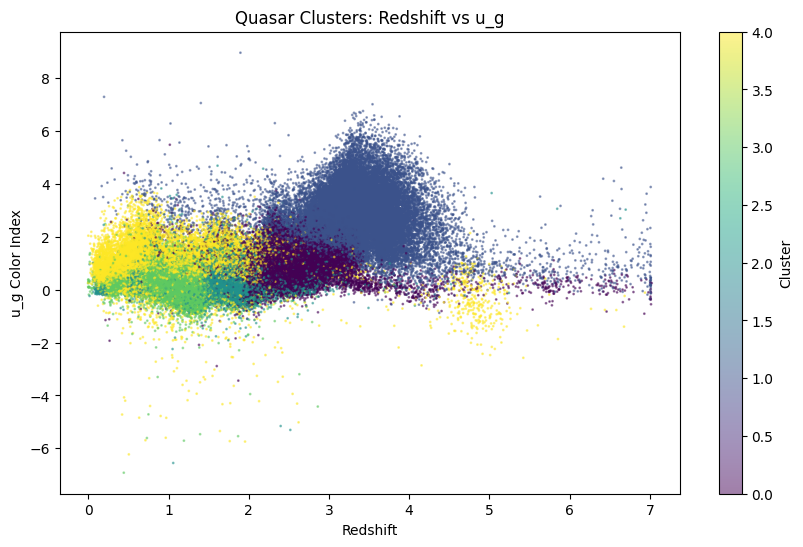

In [51]:
# Scatterplot
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_clean["redshift"],
    df_clean["u_g"],
    c=df_clean["cluster"],
    s=1,
    alpha=0.5
)

plt.xlabel("Redshift")
plt.ylabel("u_g Color Index")

plt.title("Quasar Clusters: Redshift vs u_g")

plt.colorbar(label="Cluster")

plt.show()

Well, by-golly that looks like crap... Need to fix the cluster legend, as it thinks it is a scale instead of categories.

We got some clustering going on, and some definite overlap

Let's clean up that plot.

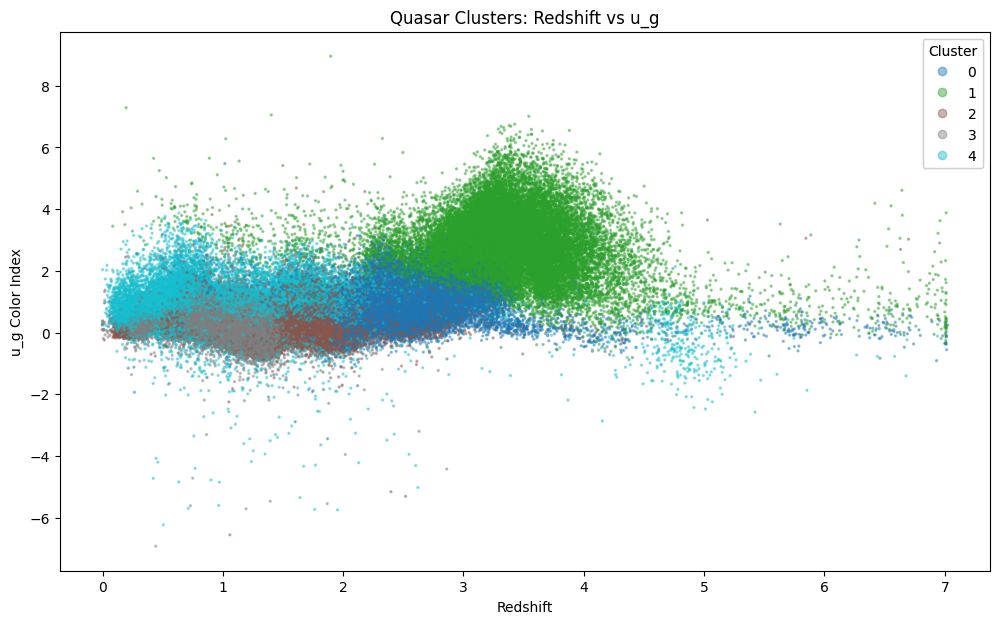

In [52]:
# Create a cleaner cluster visualization using categorical colors.

plt.figure(figsize=(12,7))

# Create scatter plot with distinct cluster colors.
scatter = plt.scatter(
    df_clean["redshift"],
    df_clean["u_g"],
    c=df_clean["cluster"],
    cmap="tab10",   # categorical colormap
    s=2,
    alpha=0.4
)


plt.xlabel("Redshift")
plt.ylabel("u_g Color Index")

plt.title("Quasar Clusters: Redshift vs u_g")

# Create a legend for clusters.
legend = plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.gca().add_artist(legend)

plt.show()

That is much more clear.

So, looks like we have some definite overlap in the categories, but it does not look random. There is some structure there. We have some clear divisions in the features.

Cluster 1 (Green) - high redshift, high u_g, fairly concentrated and coherent.

Cluster 3 (Gray) - lower redshift, compact and concentrated around a low u_g.

Cluster 0 (Blue) - seems to bridge several regions in the space

Cluster 4 (Cyan) - lower redshifts, even dipping into negative u_g, redshift tail spans the entire graph

A little of the insights we have gained thus far.
Quasars to not neatly package themselves into isolated categories. We have overlapping categories and structured regions of parameters (although somewhat continuous).

One thing to mention, is that we are using K-Means which typically 'wants' spherical clusters and uses Euclidean distance. It could oversimplify countinuous astrological populations (I am not an astrophysicist, haha)/

Ok, that's only 2 dimensions, let's get busy on getting a principle component analysis (PCA)

In [53]:
# Import PCA
from sklearn.decomposition import PCA

# Create a PCA model that reduces the dataset to 2 dimensions.
pca = PCA(n_components=2)

# Apply PCA transformation to the scaled clustering features.
pca_components = pca.fit_transform(scaled_features)

# Create a Dataframe containing the PCA coordinates.
pca_df = pd.DataFrame({
    "PC1": pca_components[:, 0],
    "PC2": pca_components[:, 1],
    "cluster": df_clean["cluster"]
})

# Display the explained variance ratio.
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.32829545 0.22340688]


Our explained variance means we have 32.8% and 22.3% for our PC1 and PC2 respectively. Therefore we have over half od the variability in the 5 dimensions covered.

In short, "Quasars are complicated" --haha
Quasars do not fit in a single dominant patter.
Clustering is likely manufactured on several interacting variables.
But, there is some structer there.

Let do the plot

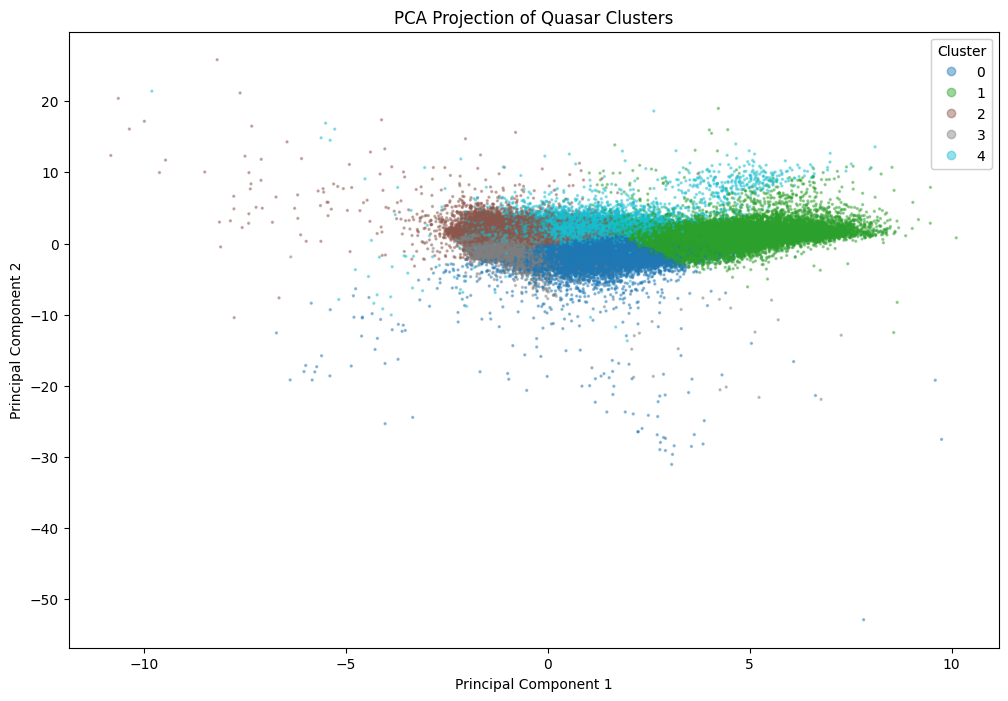

In [54]:
# Create a PCA scatter plot showing cluster separation

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="tab10",
    s=2,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection of Quasar Clusters")

# Create legend.
legend = plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.gca().add_artist(legend)

plt.show()

Oh ho, now we are cooking with spice. We are seeing some major separation in the clusters.

Some plump, dense regionality with these clusters. Coherent with clear centers, not random, for sure. Some sort of meaning ful subgroup structure exists.

Green and Cyan have clear separation, the others overlap in the central region. Green especially has stayed very distinct across all of the analysis. Boundaries of the clusters are soft, like we would expect with anything natural.

Quasar population behavior may be better represented by partially continous populations rather than discrete categories.

Let's see how influential the features contribute to the PCs

In [55]:
# Create a Dataframe showing how strongly each feature
# contributes to each PC.

loading_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=[
        "redshift",
        "u_g",
        "g_r",
        "r_i",
        "i_z"
    ]
)

# Display PCA loading values.
loading_df

,PC1,PC2
redshift,0.633135,-0.089295
u_g,0.686559,0.053709
g_r,0.329838,0.403958
r_i,-0.060094,0.703870
i_z,0.123986,-0.574915


So, it looks like PC1 was dominated by redshift and u_g. That's pretty neat, as that is a known relationship that I just found in my data without knowing what I am doing, haha. SDSS has an article about that, [here](https://voyages.sdss.org/preflight/light/redshift/)

PC2 looks like it is much more about the spectral realm. Which is great, as that means the clustering was not dominated by redshift. PC2 seems more about the spectral energy distribution and color balance between the bands.

| Finding                                 | Evidence           |
| --------------------------------------- | ------------------ |
| Quasars form structured populations     | K-Means clusters   |
| Populations overlap continuously        | PCA + scatterplots |
| High-redshift subgroup exists           | Cluster 1          |
| Redshift strongly affects structure     | PC1 loadings       |
| Spectral/color variation also matters   | PC2 loadings       |
| Clustering is not purely distance-based | PCA separation     |

